In [2]:
import os, pickle, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold
DATA = '../data'
SEED = 1          # paper notebook uses random_state=1
N_SPLITS = 4      # paper notebook uses 4 folds
df = pd.read_csv(f'{DATA}/data_curated.csv')
print(df.shape)
df[['category','material','special_version']].nunique()

(359, 10)


category            5
material            4
special_version    49
dtype: int64

edges: [  14.     38.32  104.87  287.02  785.55 2150.  ]
                  min          max  size
price_bin                               
1           14.000000    37.000000   146
2           38.428571   101.000000   153
3          108.000000   257.333333    46
4          322.400000   600.000000    10
5          800.000000  2150.000000     4


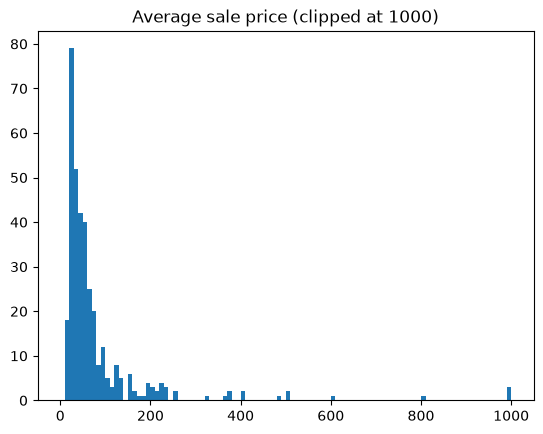

In [3]:
#price bins 
#5 equal-width bins
#Edges = exp(linspace(log min, log max, 6))

p = df['average_sale_price'].to_numpy()
edges = np.exp(np.linspace(np.log(p.min()), np.log(p.max()), 6))

# searchsorted on inner edges: [e0,e1)->1 ... [e4,e5]->5 (max value included in bin 5, no float edge issue)

df['price_bin'] = np.searchsorted(edges[1:-1], p, side='right') + 1
print('edges:', np.round(edges, 2))
print(df.groupby('price_bin')['average_sale_price'].agg(['min','max','size']))
assert df['price_bin'].value_counts().sort_index().tolist() == [146,153,46,10,4], 'bin counts differ from paper'
plt.hist(np.clip(p, 0, 1000), bins=np.arange(0, 1010, 10)); plt.title('Average sale price (clipped at 1000)'); plt.show()

In [4]:
#search volume
#log, then min-max to [0, 1] (paper section 3)
lv = np.log(df['search_volume'].to_numpy(dtype=float))
df['search_volume_normalized'] = (lv - lv.min()) / (lv.max() - lv.min())
df['search_volume_normalized'].describe()

count    359.000000
mean       0.627750
std        0.204231
min        0.000000
25%        0.557973
50%        0.673370
75%        0.765886
max        1.000000
Name: search_volume_normalized, dtype: float64

In [5]:
"""Feature matrices
X_onehot: [search_volume_normalized, one-hot(category, material, special_version)] 
        for linear/RBF SVM, trees, XGBoost.
        
X_ordinal: [search_volume_normalized, ordinal(category), ordinal(material), ordinal(special_version)] 
        for the custom kernel (column order matters: kernel indexes columns 0-3).
        
Encoders are fit on the full dataset, same as the paper notebook (unsupervised, no label leakage). """

cat_cols = ['category', 'material', 'special_version']
sv = df[['search_volume_normalized']].to_numpy()
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_onehot = np.hstack([sv, ohe.fit_transform(df[cat_cols])])
onehot_names = ['search_volume_normalized'] + list(ohe.get_feature_names_out(cat_cols))

oe = OrdinalEncoder()
X_ordinal = np.hstack([sv, oe.fit_transform(df[cat_cols])])
ordinal_names = ['search_volume_normalized'] + cat_cols

y = df['price_bin'].to_numpy()          # labels 1..5 (paper's bin numbering)
print(X_onehot.shape, X_ordinal.shape, np.bincount(y)[1:])

(359, 59) (359, 4) [146 153  46  10   4]


In [6]:
#Folds
#StratifiedKFold(4, shuffle=True, random_state=1), stored as a list of (train_idx, test_idx).
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
folds = [(tr, te) for tr, te in skf.split(X_onehot, y)]
for i, (tr, te) in enumerate(folds):
    print(i, len(tr), len(te), np.bincount(y[te], minlength=6)[1:])

0 269 90 [36 39 12  2  1]
1 269 90 [37 38 11  3  1]
2 269 90 [37 38 11  3  1]
3 270 89 [36 38 12  2  1]


In [7]:
np.savez(f'{DATA}/processed.npz',
         X_onehot=X_onehot, X_ordinal=X_ordinal,
         y=y,                      # 1..5
         y0=y - 1,                 # 0..4, for XGBoost
         onehot_names=np.array(onehot_names), ordinal_names=np.array(ordinal_names))
with open(f'{DATA}/folds.pkl', 'wb') as f:
    pickle.dump(folds, f)
df.to_csv(f'{DATA}/processed_table.csv', index=False)
print(sorted(os.listdir(DATA)))

['data_curated.csv', 'folds.pkl', 'processed.npz', 'processed_table.csv']


In [8]:
d = np.load(f'{DATA}/processed.npz'); f = pickle.load(open(f'{DATA}/folds.pkl', 'rb'))
assert d['X_onehot'].shape == (359, 59) and d['X_ordinal'].shape == (359, 4)
assert np.bincount(d['y'])[1:].tolist() == [146, 153, 46, 10, 4]
assert len(f) == 4 and sum(len(te) for _, te in f) == 359
print('processed.npz and folds.pkl OK')

processed.npz and folds.pkl OK
